In [101]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs, make_swiss_roll
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn

## 1) Test on Gaussian blobs data

### a) Generating data

In [67]:
# Generate 2 Gaussian blobs
X, labels_X = make_blobs(n_samples=100, centers=[[0, 0]], cluster_std=1.0, random_state=42)
Y, labels_Y = make_blobs(n_samples=100, centers=[[0, 10], [0, -10]], cluster_std=1.0, random_state=24)

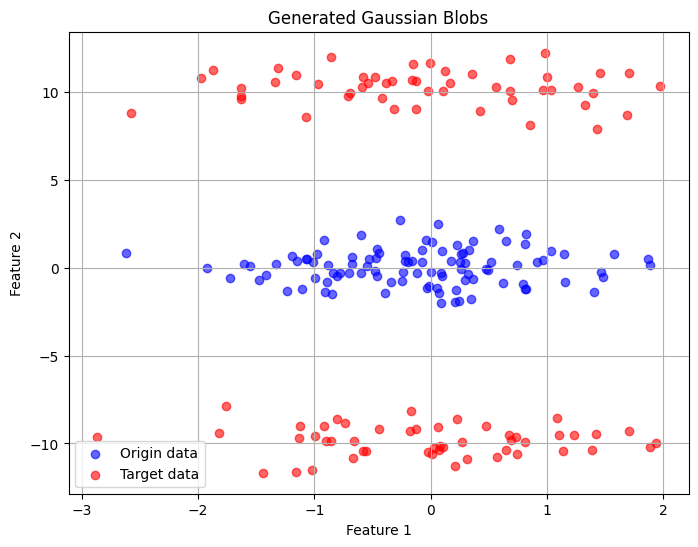

In [72]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Origin data', alpha=0.6)
plt.scatter(Y[:, 0], Y[:, 1], c='red', label='Target data', alpha=0.6)

plt.legend()
plt.title('Generated Gaussian Blobs')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### b) Testing the model


Entropic OT plan (reg=0.1)
Sinkhorn distance (reg=0.1): 142.85
Dual distance (reg=0.1): 87.36


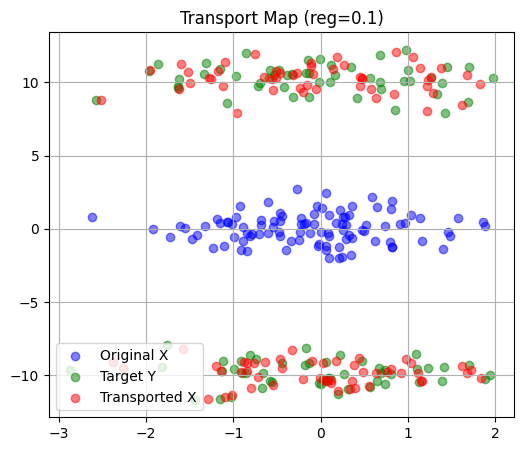


Entropic OT plan (reg=1.0)
Sinkhorn distance (reg=1.0): 140.97
Dual distance (reg=1.0): 97.29


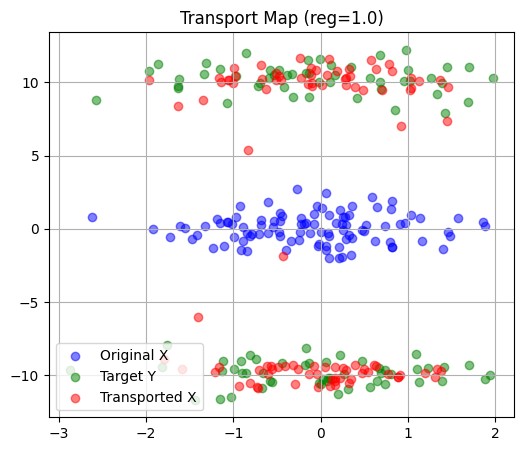


Entropic OT plan (reg=10.0)
Sinkhorn distance (reg=10.0): 132.17
Dual distance (reg=10.0): 186.06


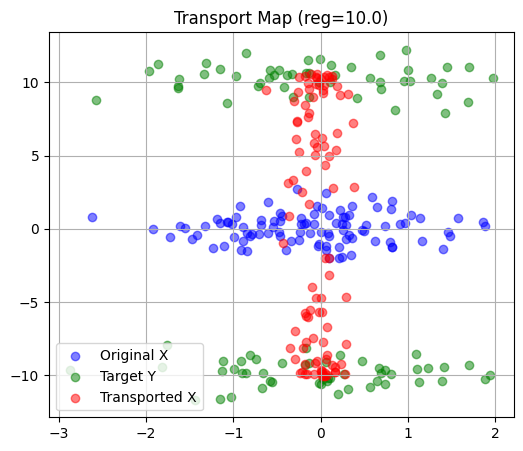

In [65]:
def sinkhorn_loss(X1, X2):
    return np.linalg.norm(X1 - X2)

reg_list = [0.1, 1.0, 10.0]

for reg in reg_list:
    print(f"\nEntropic OT plan (reg={reg})")

    # Step 1: Define geometry
    geom = pointcloud.PointCloud(X, Y, epsilon=reg)

    # Step 2: Define the problem
    problem = linear_problem.LinearProblem(geom)

    # Step 3: Solve with Sinkhorn
    solver = sinkhorn.Sinkhorn()
    out = solver(problem)

    # Step 4: Transport using dual potentials
    entropic_map = out.to_dual_potentials()
    transported_X = entropic_map.transport(X)

    # Step 5: Compute distances
    sink_dist = sinkhorn_loss(transported_X, Y)
    dual_dist = entropic_map.distance(X, Y)
    print(f"Sinkhorn distance (reg={reg}): {sink_dist:.2f}")
    print(f"Dual distance (reg={reg}): {dual_dist:.2f}")

    # Step 7: Visualization
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c='blue', label='Original X', alpha=0.5)
    plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target Y', alpha=0.5)
    plt.scatter(transported_X[:, 0], transported_X[:, 1], c='red', label='Transported X', alpha=0.5)
    plt.title(f"Transport Map (reg={reg})")
    plt.legend()
    plt.grid(True)
    plt.show()


## 2) Test on swiss roll data

### a) Generating data

In [97]:
X, t_x = make_swiss_roll(n_samples=200, noise=1.5, random_state=42)
Y, t_y = make_swiss_roll(n_samples=200, noise=0, random_state=42)

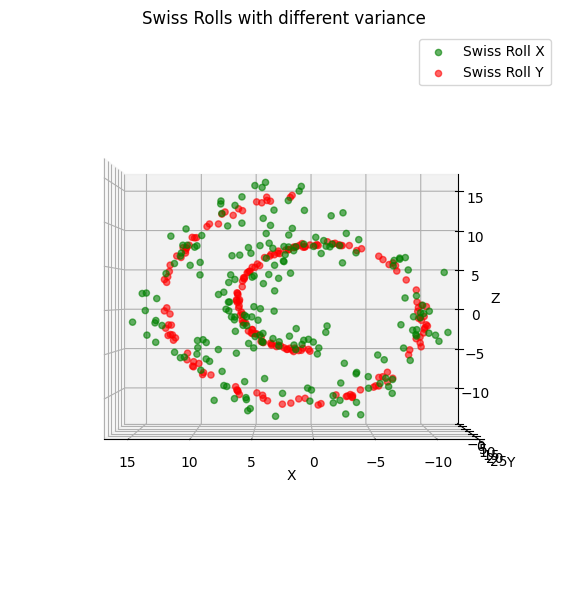

In [106]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot X
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='green', label='Swiss Roll X', alpha=0.6)

# Plot Y
ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], c='red', label='Swiss Roll Y', alpha=0.6)

# Customize plot
ax.set_title('Swiss Rolls with different variance')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

ax.view_init(elev=0, azim=90)

plt.tight_layout()
plt.show()

### b) Testing the model


Entropic OT plan (reg=0.1)
Sinkhorn distance (reg=0.1): 25.47
Dual distance (reg=0.1): 6.72


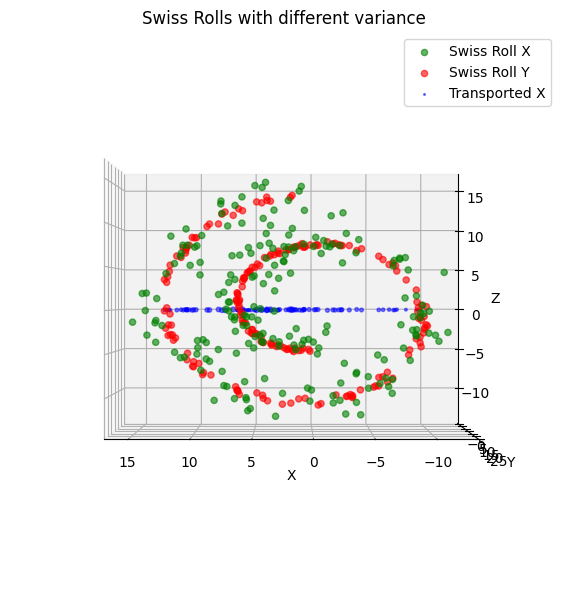


Entropic OT plan (reg=1.0)
Sinkhorn distance (reg=1.0): 23.56
Dual distance (reg=1.0): 20.53


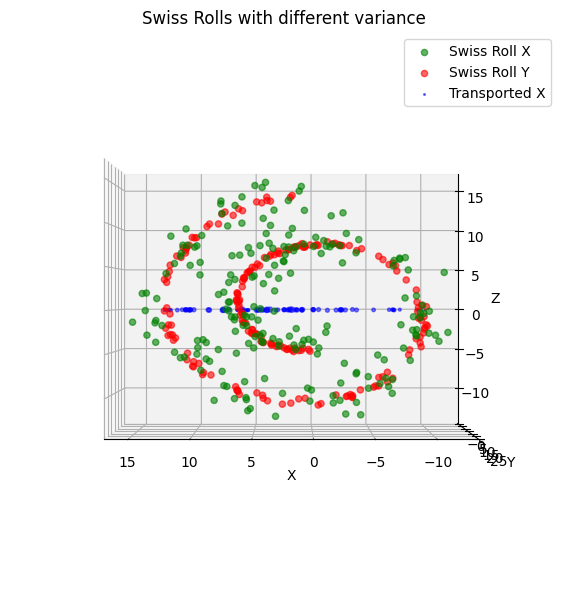


Entropic OT plan (reg=10.0)
Sinkhorn distance (reg=10.0): 26.47
Dual distance (reg=10.0): 148.43


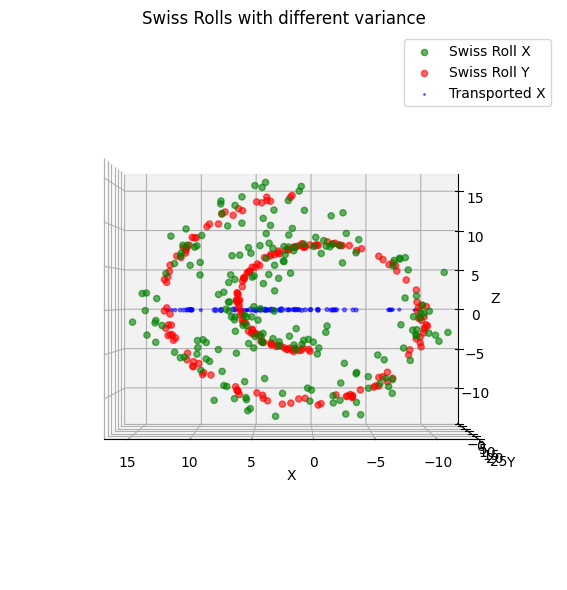

In [105]:
def sinkhorn_loss(X1, X2):
    return np.linalg.norm(X1 - X2)

reg_list = [0.1, 1.0, 10.0]

for reg in reg_list:
    print(f"\nEntropic OT plan (reg={reg})")

    # Step 1: Define geometry
    geom = pointcloud.PointCloud(X, Y, epsilon=reg)

    # Step 2: Define the problem
    problem = linear_problem.LinearProblem(geom)

    # Step 3: Solve with Sinkhorn
    solver = sinkhorn.Sinkhorn()
    out = solver(problem)

    # Step 4: Transport using dual potentials
    entropic_map = out.to_dual_potentials()
    transported_X = entropic_map.transport(X)

    # Step 5: Compute distances
    sink_dist = sinkhorn_loss(transported_X, Y)
    dual_dist = entropic_map.distance(X, Y)
    print(f"Sinkhorn distance (reg={reg}): {sink_dist:.2f}")
    print(f"Dual distance (reg={reg}): {dual_dist:.2f}")

    # Step 7: Visualization
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='green', label='Swiss Roll X', alpha=0.6)
    ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], c='red', label='Swiss Roll Y', alpha=0.6)
    plt.scatter(transported_X[:, 0], transported_X[:, 1], transported_X[:, 2], c='blue', label='Transported X', alpha=0.5)
    
    ax.set_title('Swiss Rolls with different variance')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    
    ax.view_init(elev=0, azim=90)
    
    plt.tight_layout()
    plt.show()

## 3) Test on the Cifar dataset